In [1]:
import pandas as pd
import pymc as pm
from patsy import dmatrix
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import japanize_matplotlib

In [2]:
df = pd.read_csv("../data/marketing_AB.csv", index_col=0)
df_sub = pd.read_csv("../data/df_sub_cross_random_effect_v2.csv", index_col=0)
df["group_idx"] = df["test group"].map({"psa": 0, "ad": 1})
df["log_ads"] = np.log1p(df["total ads"])

print(len(df))
print(len(df_sub))

x_centered = (df_sub["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
x_centered.values

588101
88215


array([ 0.23230312,  0.37318454,  0.37318454, ...,  1.3539536 ,
       -0.67049326,  1.09520149], shape=(88215,))

In [3]:
num_knots = 5
knot_list = np.quantile(x_centered, np.linspace(0, 1, num_knots + 2))
print("knots:", knot_list)

B = dmatrix(
    "bs(x, knots=knots, degree=3, include_intercept=False) - 1",
    {"x": x_centered, "knots": knot_list},
)
B = np.asarray(B)
print("Bの形状:", B.shape)
    

knots: [-1.62283808 -1.0219754  -0.53686595  0.06399673  0.45580528  0.97404722
  4.26372395]
Bの形状: (88215, 10)


In [4]:
#サブサンプリングで実施
n_basis = B.shape[1]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_sub["day_idx"] = pd.Categorical(df_sub["most ads day"], categories=day_order).codes

n_days = len(day_order)

df_sub["hour_idx"] = df_sub["most ads hour"].astype(int)
n_hours = 24

day_idx_sub = df_sub["day_idx"].values
hour_idx_sub = df_sub["hour_idx"].values
log_ads_std_sub = (df_sub["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
converted_sub = df_sub["converted"].astype(int).values
group_idx_sub = df_sub["group_idx"].values

with pm.Model() as model_spline:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)

    sigma_day = pm.HalfNormal("sigma_day", sigma=0.5)
    day_offset_raw = pm.Normal("day_offset_raw", sigma=0.5, shape=n_days)
    day_effect = pm.Deterministic("day_effect", sigma_day * day_offset_raw)

    sigma_hour = pm.HalfNormal("sigma_hour", sigma=0.5)
    hour_offset_raw = pm.Normal("hour_offset_raw", sigma=0.5, shape=n_hours)
    hour_effect = pm.Deterministic("hour_effect", sigma_hour * hour_offset_raw)

    sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.15)
    beta_spline = pm.GaussianRandomWalk(
        "beta_spline", sigma=sigma_rw, init_dist=pm.Normal.dist(0, 0.01), shape=n_basis
    )

    spline_effect = pm.math.dot(B, beta_spline)
    logit_p = (
        beta0
        + day_effect[day_idx_sub]
        + hour_effect[hour_idx_sub]
        + beta1 * group_idx_sub
        + spline_effect
        + beta3 * group_idx_sub * x_centered
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    obs = pm.Bernoulli("obs", p=p, observed=converted_sub)    

/tmp/ipykernel_3334/2683398799.py:19: DeprecationWarning: `pymc.logit` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.math.logit` instead.
  beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)


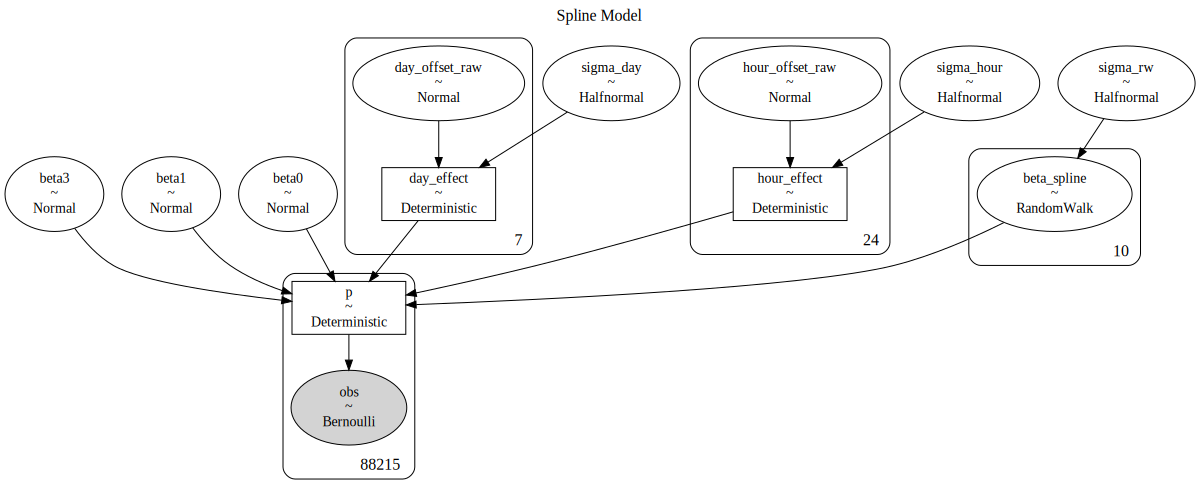

In [5]:
g = pm.model_to_graphviz(model_spline)
g.graph_attr.update(
    label="Spline Model",
    labelloc="t",
    fontsize="16"
)
g.render(filename="../models/spline_model", format="png", cleanup=True)
g

In [6]:
with model_spline:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [beta0, beta1, beta3, beta_spline, day_offset_raw, hour_offset_raw, obs, sigma_day, sigma_hour, sigma_rw]


In [7]:
p_pred = prior.prior["p"].values.flatten()
print(f"pの最小値: {p_pred.min()}, pの平均値:{p_pred.mean()}, pの最大値:{p_pred.max()}")
print(f"pの95%範囲:{np.percentile(p_pred, 2.5)}~{np.percentile(p_pred, 97.5)}")

pの最小値: 6.700123899751312e-05, pの平均値:0.04141923255879245, pの最大値:0.8494388657464044
pの95%範囲:0.0029928602296668398~0.1825171254325283


In [8]:
print(f"サンプル総数: {len(p_pred):,}")
print(f"p > 0.3 の割合: {(p_pred > 0.3).mean():.6f}")
print(f"p > 0.5 の割合: {(p_pred > 0.5).mean():.6f}")

サンプル総数: 26,464,500
p > 0.3 の割合: 0.007834
p > 0.5 の割合: 0.001110


In [9]:
beta_spline_prior = prior.prior["beta_spline"].values  # shape: (chain, draw, n_basis)
print("beta_splineの各次元ごとの標準偏差:")
print(beta_spline_prior.std(axis=(0,1)))
print("\nbeta_splineの各次元ごとの最大絶対値:")
print(np.abs(beta_spline_prior).max(axis=(0,1)))

beta_splineの各次元ごとの標準偏差:
[0.01044629 0.13383687 0.21954224 0.28107074 0.29625396 0.33892361
 0.37184763 0.39561748 0.42988363 0.44316691]

beta_splineの各次元ごとの最大絶対値:
[0.03044054 0.5969901  1.06673549 2.33799297 1.50590548 2.0868431
 2.44874361 2.82679543 2.94432472 3.06223071]


In [10]:
sigma_rw_pred = prior.prior["sigma_rw"].values.flatten()
print(f"sigma_rwの最小値: {sigma_rw_pred.min()}, sigma_rwの平均値:{sigma_rw_pred.mean()}, sigma_rwの最大値:{sigma_rw_pred.max()}")
print(f"sigma_rwの95%範囲:{np.percentile(sigma_rw_pred, 2.5)}~{np.percentile(sigma_rw_pred, 97.5)}")

sigma_rwの最小値: 0.0017999763306052415, sigma_rwの平均値:0.11514199730856615, sigma_rwの最大値:0.6139331210110278
sigma_rwの95%範囲:0.004988079623515643~0.31757685882699743


In [11]:
beta0_prior = prior.prior["beta0"].values.flatten()
beta_spline_mean_prior = prior.prior["beta_spline"].values.mean(axis=-1).flatten()

print(f"相関係数: {np.corrcoef(beta0_prior, beta_spline_mean_prior)[0,1]:.3f}")
print(f"beta_splineの平均(サンプルごと)の標準偏差: {beta_spline_mean_prior.std():.3f}")
    

相関係数: 0.015
beta_splineの平均(サンプルごと)の標準偏差: 0.257


In [12]:
with model_spline:
    trace_spline = pm.sample(draws=1000, tune=1000, chains=4, cores=4, nuts_sampler="numpyro", target_accept=0.9, random_seed=42)


NUTS[numpyro]: [beta0, beta1, beta3, sigma_day, day_offset_raw, sigma_hour, hour_offset_raw, sigma_rw, beta_spline]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%| | 0/2000 [00:00
  0%|     | 0/2000 [00:00<?, ?it/s]
Compiling.. :   0%| | 0/2000 [00:00

  0%|     | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%| | 0/2000 [00:00


  0%|     | 0/2000 [00:00<?, ?it/s]


Running chain 0:   0%| | 0/2000 [00
Running chain 1:   0%| | 0/2000 [00

Running chain 2:   0%| | 0/2000 [00


Running chain 3:   0%| | 0/2000 [00


Running chain 3:   5%| | 100/2000 [
Running chain 1:   5%| | 100/2000 [

Running chain 0:   5%| | 100/2000 [
Running chain 1:  10%| | 200/2000 [


Running chain 3:  10%| | 200/2000 [

Running chain 0:  10%| | 200/2000 [
Running chain 1:  15%|▏| 300/2000 [


Running chain 0:  15%|▏| 300/2000 [

Running chain 2:  15%|▏| 300/2000 [
Running chain 1:  20%|▏| 400/2000 [


Running chain 0:  20%|▏| 400/2000

In [13]:
print(f"divergences: {trace_spline.sample_stats.diverging.sum().item()}")
az.summary(trace_spline, var_names=["beta0", "beta1", "beta3", "sigma_rw", "beta_spline"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-5.62,0.35,-6.2,-5.1,827,1189,1.00,0.012,0.0084
beta1,-0.107,0.143,-0.33,0.12,1937,2283,1.00,0.0032,0.0023
beta3,0.423,0.103,0.26,0.59,1138,1516,1.00,0.0031,0.0022
sigma_rw,0.76,0.076,0.64,0.89,4062,3055,1.00,0.0012,0.00084
beta_spline[0],-0.0004,0.0099,-0.016,0.015,4543,2927,1.00,0.00015,9.9e-05
beta_spline[1],-0.09,0.42,-0.76,0.57,2747,2586,1.00,0.008,0.0058
beta_spline[2],0.22,0.37,-0.38,0.82,2096,2634,1.00,0.0081,0.0059
beta_spline[3],0.51,0.32,0.011,1,1462,2002,1.00,0.0083,0.006
beta_spline[4],0.47,0.32,-0.028,0.97,1189,1645,1.00,0.0092,0.0065
beta_spline[5],1.1,0.3,0.63,1.6,867,1432,1.00,0.01,0.0073


In [14]:
#サブサンプリングで実施
n_basis = B.shape[1]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_sub["day_idx"] = pd.Categorical(df_sub["most ads day"], categories=day_order).codes

n_days = len(day_order)

df_sub["hour_idx"] = df_sub["most ads hour"].astype(int)
n_hours = 24

day_idx_sub = df_sub["day_idx"].values
hour_idx_sub = df_sub["hour_idx"].values
log_ads_std_sub = (df_sub["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
converted_sub = df_sub["converted"].astype(int).values
group_idx_sub = df_sub["group_idx"].values

with pm.Model() as model_spline_v1:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)

    sigma_day = pm.HalfNormal("sigma_day", sigma=0.5)
    day_offset_raw = pm.Normal("day_offset_raw", sigma=0.5, shape=n_days)
    day_effect = pm.Deterministic("day_effect", sigma_day * day_offset_raw)

    sigma_hour = pm.HalfNormal("sigma_hour", sigma=0.5)
    hour_offset_raw = pm.Normal("hour_offset_raw", sigma=0.5, shape=n_hours)
    hour_effect = pm.Deterministic("hour_effect", sigma_hour * hour_offset_raw)

    sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.5)
    beta_spline = pm.GaussianRandomWalk(
        "beta_spline", sigma=sigma_rw, init_dist=pm.Normal.dist(0, 0.01), shape=n_basis
    )

    spline_effect = pm.math.dot(B, beta_spline)
    logit_p = (
        beta0
        + day_effect[day_idx_sub]
        + hour_effect[hour_idx_sub]
        + beta1 * group_idx_sub
        + spline_effect
        + beta3 * group_idx_sub * x_centered
    )

    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    obs = pm.Bernoulli("obs", p=p, observed=converted_sub)    

In [15]:
with model_spline_v1:
    trace_spline_v1 = pm.sample(draws=1000, tune=1000, chains=4, cores=4, nuts_sampler="numpyro", target_accept=0.9, random_seed=42)


NUTS[numpyro]: [beta0, beta1, beta3, sigma_day, day_offset_raw, sigma_hour, hour_offset_raw, sigma_rw, beta_spline]
Compiling.. :   0%| | 0/2000 [00:00
  0%|     | 0/2000 [00:00<?, ?it/s]
Compiling.. :   0%| | 0/2000 [00:00

  0%|     | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%| | 0/2000 [00:00


  0%|     | 0/2000 [00:00<?, ?it/s]


Running chain 0:   0%| | 0/2000 [00
Running chain 1:   0%| | 0/2000 [00

Running chain 2:   0%| | 0/2000 [00


Running chain 3:   0%| | 0/2000 [00


Running chain 0:   5%| | 100/2000 [

Running chain 2:   5%| | 100/2000 [
Running chain 1:   5%| | 100/2000 [


Running chain 0:  10%| | 200/2000 [

Running chain 2:  10%| | 200/2000 [
Running chain 1:  10%| | 200/2000 [
Running chain 1:  15%|▏| 300/2000 [


Running chain 0:  15%|▏| 300/2000 [

Running chain 2:  15%|▏| 300/2000 [
Running chain 1:  20%|▏| 400/2000 [


Running chain 0:  20%|▏| 400/2000 [

Running chain 2:  20%|▏| 400/2000 [
Running chain 1:  25%|▎| 500/2000 [


Running chain 0:  25%|▎| 500/2000

In [16]:
print(f"divergences: {trace_spline_v1.sample_stats.diverging.sum().item()}")
az.summary(trace_spline_v1, var_names=["beta0", "beta1", "beta3", "sigma_rw", "beta_spline"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-5.68,0.36,-6.3,-5.1,888,1419,1.00,0.012,0.0085
beta1,-0.083,0.149,-0.31,0.16,2150,2433,1.00,0.0032,0.0022
beta3,0.393,0.108,0.22,0.57,1187,1617,1.00,0.0031,0.0023
sigma_rw,1.357,0.223,1,1.7,3967,2944,1.00,0.0035,0.0026
beta_spline[0],-0.0001,0.0098,-0.016,0.015,4990,3086,1.00,0.00014,9.2e-05
beta_spline[1],-0.21,0.54,-1.1,0.63,3408,2985,1.00,0.0092,0.0064
beta_spline[2],0.27,0.45,-0.44,0.97,2647,2540,1.00,0.0086,0.0062
beta_spline[3],0.5,0.34,-0.039,1.1,1817,2334,1.00,0.0081,0.0058
beta_spline[4],0.57,0.33,0.05,1.1,1276,2030,1.00,0.0092,0.0065
beta_spline[5],1.05,0.32,0.56,1.6,946,1437,1.00,0.01,0.0076


In [17]:
# beta_spline[6]周辺、つまりknotの6番目(0.974)近辺のデータを直接見る
mask = (x_centered > 0.7) & (x_centered < 1.4)
print(f"該当区間のn: {mask.sum()}")
print(f"該当区間のCVR: {converted_sub[mask].mean():.4f}")
print(f"該当区間のxの分布:")
print(pd.Series(x_centered[mask]).describe())

# さらに細かく見る:0.1刻みでCVRの変化を見る
df_local = pd.DataFrame({"x": x_centered, "y": converted_sub})
df_local["x_round"] = (df_local["x"] * 10).round() / 10
print(df_local[(df_local["x"] > 0.5) & (df_local["x"] < 1.5)].groupby("x_round")["y"].agg(["size", "mean"]))

該当区間のn: 13695
該当区間のCVR: 0.0513
該当区間のxの分布:
count    13695.000000
mean         1.013350
std          0.196509
min          0.724667
25%          0.833166
50%          0.995452
75%          1.184648
max          1.394915
Name: log_ads, dtype: float64
         size      mean
x_round                
0.5      1029  0.012634
0.6      3776  0.019597
0.7      2386  0.023051
0.8      2831  0.028612
0.9      2241  0.032575
1.0      2162  0.049491
1.1      1974  0.055724
1.2      1440  0.077083
1.3      1532  0.084856
1.4      1430  0.102797
1.5       570  0.107018


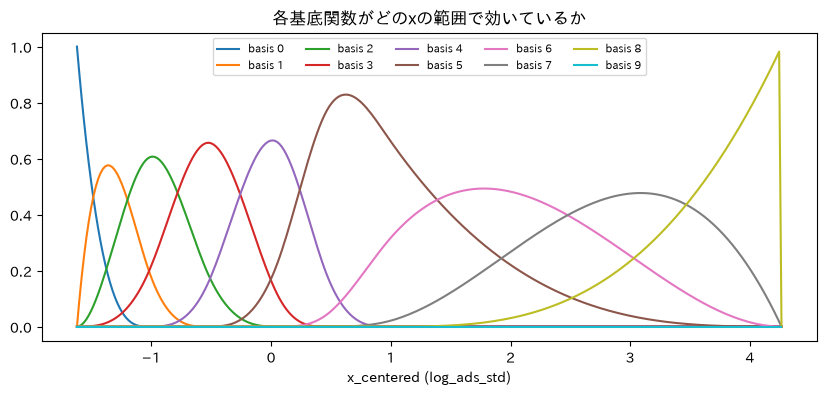

In [18]:
x_grid = np.linspace(x_centered.min(), x_centered.max(), 300)
B_grid = np.asarray(dmatrix(
    "bs(x, knots=knots, degree=3, include_intercept=False) - 1",
    {"x": x_grid, "knots": knot_list},
))

plt.figure(figsize=(10, 4))
for i in range(B_grid.shape[1]):
    plt.plot(x_grid, B_grid[:, i], label=f"basis {i}")
plt.legend(ncol=5, fontsize=8)
plt.xlabel("x_centered (log_ads_std)")
plt.title("各基底関数がどのxの範囲で効いているか")
plt.show()

In [19]:
# 等間隔knotを試作
knot_list_eq = np.linspace(x_centered.min(), x_centered.max(), 9)[1:-1]  # 内部knot、境界を除く
print("等間隔knots:", knot_list_eq)

# 各区間のデータ件数を確認
bins_eq = np.digitize(x_centered, knot_list_eq)
counts_eq = pd.Series(bins_eq).value_counts().sort_index()
print(counts_eq)

等間隔knots: [-0.88701782 -0.15119757  0.58462268  1.32044294  2.05626319  2.79208345
  3.5279037 ]
0    18593
1    18736
2    26055
3    16324
4     6582
5     1635
6      265
7       25
Name: count, dtype: int64


In [20]:
for num_knots_try in [5, 7, 9]:
    knot_list_try = np.quantile(x_centered, np.linspace(0, 1, num_knots_try + 2)[1:-1])
    print(f"\n--- num_knots={num_knots_try} ---")
    print("knots:", np.round(knot_list_try, 3))
    print("最後の区間の幅(knot[-1]からxの最大値まで):", x_centered.max() - knot_list_try[-1])

    # 各knot区間のデータ件数も確認
    bins_try = np.digitize(x_centered, knot_list_try)
    print(pd.Series(bins_try).value_counts().sort_index())


--- num_knots=5 ---
knots: [-1.022 -0.537  0.064  0.456  0.974]
最後の区間の幅(knot[-1]からxの最大値まで): 3.2896767289212083
0    14311
1    12306
2    16542
3    15131
4    15212
5    14713
Name: count, dtype: int64

--- num_knots=7 ---
knots: [-1.271 -0.829 -0.319  0.064  0.329  0.665  1.167]
最後の区間の幅(knot[-1]からxの最大値まで): 3.0962421509200557
0     8453
1    10140
2    14455
3    10111
4    10596
5    11789
6    11594
7    11077
Name: count, dtype: int64

--- num_knots=9 ---
knots: [-1.271 -1.022 -0.67  -0.319  0.064  0.282  0.531  0.833  1.296]
最後の区間の幅(knot[-1]からxの最大値まで): 2.9675825464282553
0     8453
1     5858
2     7786
3    10951
4    10111
5     8358
6     9222
7     9282
8     9277
9     8917
Name: count, dtype: int64


In [21]:
print(pd.Series(x_centered).describe(percentiles=[0.9, 0.95, 0.99, 0.995, 0.999]))

count    88215.000000
mean         0.001455
std          0.999590
min         -1.622838
50%          0.063997
90%          1.296141
95%          1.667326
99%          2.407364
99.5%        2.654668
99.9%        3.136718
max          4.263724
Name: log_ads, dtype: float64


In [22]:
# 99%点(2.407)を超えるデータの特徴を見る
threshold = np.percentile(x_centered, 99)
mask_outlier = x_centered > threshold

print(f"該当件数: {mask_outlier.sum()} (全体の{mask_outlier.mean()*100:.3f}%)")
print(f"CVR(外れ値グループ): {converted_sub[mask_outlier].mean():.4f}")
print(f"CVR(それ以外): {converted_sub[~mask_outlier].mean():.4f}")
print(f"xの分布(外れ値グループ):")
print(pd.Series(x_centered[mask_outlier]).describe())

該当件数: 870 (全体の0.986%)
CVR(外れ値グループ): 0.1540
CVR(それ以外): 0.0246
xの分布(外れ値グループ):
count    870.000000
mean       2.740750
std        0.302687
min        2.411501
25%        2.516351
50%        2.659331
75%        2.881141
max        4.263724
Name: log_ads, dtype: float64


In [23]:
df_outlier = pd.DataFrame({"x": x_centered[mask_outlier], "y": converted_sub[mask_outlier]})
df_outlier["x_bin"] = pd.qcut(df_outlier["x"], q=5, duplicates="drop")
print(df_outlier.groupby("x_bin")["y"].agg(["size", "mean"]))

                size      mean
x_bin                         
(2.411, 2.49]    175  0.165714
(2.49, 2.583]    175  0.120000
(2.583, 2.729]   174  0.120690
(2.729, 2.949]   172  0.168605
(2.949, 4.264]   174  0.195402


/tmp/ipykernel_3334/3922912360.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_outlier.groupby("x_bin")["y"].agg(["size", "mean"]))


In [24]:
se_approx = np.sqrt(0.15 * 0.85 / 175)
print(f"おおよそのSE: {se_approx:.3f}")

おおよそのSE: 0.027


In [25]:
threshold = np.percentile(x_centered, 99)
x_for_spline = np.minimum(x_centered, threshold)  # 99%点でクリップ
is_outlier = (x_centered > threshold).astype(float)

# knotの再計算も、クリップ後のx_for_splineの分布に基づいて行う
knot_list_new = np.quantile(x_for_spline, np.linspace(0, 1, 7)[1:-1])
print("新しいknots:", knot_list_new)
print("最後の区間の幅:", x_for_spline.max() - knot_list_new[-1])

新しいknots: [-1.0219754  -0.53686595  0.06399673  0.45580528  0.97404722]
最後の区間の幅: 1.4333164869994488


In [26]:
# --- 基底の再構築 ---
threshold = np.percentile(x_centered, 99)
x_for_spline = np.minimum(x_centered, threshold)
is_outlier = (x_centered > threshold).astype(float)

num_knots = 5
knot_list_new = np.quantile(x_for_spline, np.linspace(0, 1, num_knots + 2)[1:-1])

B_new = np.asarray(dmatrix(
    "bs(x, knots=knots, degree=3, include_intercept=False) - 1",
    {"x": x_for_spline, "knots": knot_list_new},
))
n_basis_new = B_new.shape[1]
print("新しいB.shape:", B_new.shape)

with pm.Model() as model_spline_v2:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)

    sigma_day = pm.HalfNormal("sigma_day", sigma=0.5)
    day_offset_raw = pm.Normal("day_offset_raw", sigma=0.5, shape=n_days)
    day_effect = pm.Deterministic("day_effect", sigma_day * day_offset_raw)

    sigma_hour = pm.HalfNormal("sigma_hour", sigma=0.5)
    hour_offset_raw = pm.Normal("hour_offset_raw", sigma=0.5, shape=n_hours)
    hour_effect = pm.Deterministic("hour_effect", sigma_hour * hour_offset_raw)

    sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.15)
    beta_spline = pm.GaussianRandomWalk(
        "beta_spline",
        sigma=sigma_rw,
        init_dist=pm.Normal.dist(0, 0.01),
        shape=n_basis_new
    )
    spline_effect = pm.math.dot(B_new, beta_spline)

    beta_outlier = pm.Normal("beta_outlier", mu=0, sigma=1)

    logit_p = (
        beta0
        + day_effect[day_idx_sub]
        + hour_effect[hour_idx_sub]
        + beta1 * group_idx_sub
        + spline_effect * (1 - is_outlier)
        + beta_outlier * is_outlier
        + beta3 * group_idx_sub * x_centered
    )
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

    prior_pred = pm.sample_prior_predictive(draws=300, random_seed=42)
    

新しいB.shape: (88215, 8)


Sampling: [beta0, beta1, beta3, beta_outlier, beta_spline, day_offset_raw, hour_offset_raw, sigma_day, sigma_hour, sigma_rw]


In [27]:
p_pred = prior_pred.prior["p"].values.flatten()
print(f"pの最小値: {p_pred.min()}, pの平均値:{p_pred.mean()}, pの最大値:{p_pred.max()}")
print(f"pの95%範囲:{np.percentile(p_pred, 2.5)}~{np.percentile(p_pred, 97.5)}")
print(f"p > 0.3 の割合: {(p_pred > 0.3).mean():.6f}")
print(f"p > 0.5 の割合: {(p_pred > 0.5).mean():.6f}")

pの最小値: 9.759932189324272e-05, pの平均値:0.04649629718904962, pの最大値:0.9547181672250717
pの95%範囲:0.002541598665237554~0.18922193546315647
p > 0.3 の割合: 0.006456
p > 0.5 の割合: 0.000893


In [28]:
with model_spline_v2:
    trace_spline_v2 = pm.sample(
        draws=1000, tune=1000, chains=4, cores=4, nuts_sampler="numpyro", target_accept=0.9, random_seed=42
    )

NUTS[numpyro]: [beta0, beta1, beta3, sigma_day, day_offset_raw, sigma_hour, hour_offset_raw, sigma_rw, beta_spline, beta_outlier]
Compiling.. :   0%| | 0/2000 [00:00
  0%|     | 0/2000 [00:00<?, ?it/s]
Compiling.. :   0%| | 0/2000 [00:00

  0%|     | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%| | 0/2000 [00:00


  0%|     | 0/2000 [00:00<?, ?it/s]


Running chain 0:   0%| | 0/2000 [00
Running chain 1:   0%| | 0/2000 [00

Running chain 2:   0%| | 0/2000 [00


Running chain 0:   5%| | 100/2000 [
Running chain 1:   5%| | 100/2000 [

Running chain 0:  20%|▏| 400/2000 [
Running chain 1:  20%|▏| 400/2000 [


Running chain 3:   5%| | 100/2000 [

Running chain 0:  40%|▍| 800/2000 [
Running chain 1:  35%|▎| 700/2000 [


Running chain 3:  25%|▎| 500/2000 [

Running chain 0:  65%|▋| 1300/2000 


Running chain 3:  45%|▍| 900/2000 [
Running chain 1:  55%|▌| 1100/2000 

Running chain 0: 100%|█| 2000/2000 

Running chain 1:  70%|▋| 1400/2000 

Running chain 2:  70%|▋| 1400/2000 
Running chain 1:  90%

In [29]:
print(f"divergences: {trace_spline_v2.sample_stats.diverging.sum().item()}")
az.summary(trace_spline_v2, var_names=["beta0", "beta1", "beta3", "beta_outlier", "sigma_rw", "beta_spline"])

divergences: 171


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-3.65,0.98,-5.2,-2.1,4847,2000,1.00,0.014,0.01
beta1,0,0.302,-0.49,0.48,3608,2331,1.00,0.005,0.0034
beta3,-0.003,0.297,-0.47,0.46,4345,2473,1.00,0.0045,0.0033
beta_outlier,-0.01,0.98,-1.6,1.5,4765,2521,1.00,0.014,0.01
sigma_rw,0.14,0.087,0.032,0.3,358,378,1.01,0.0042,0.0033
beta_spline[0],-0.0002,0.0097,-0.016,0.015,3219,1572,1.00,0.00017,0.00012
beta_spline[1],0.004,0.162,-0.25,0.26,1946,1200,1.00,0.0038,0.0041
beta_spline[2],0,0.23,-0.35,0.37,1506,1178,1.00,0.0062,0.0072
beta_spline[3],0,0.28,-0.44,0.46,1291,983,1.01,0.0081,0.0089
beta_spline[4],0.01,0.32,-0.48,0.52,1184,1042,1.01,0.0098,0.011


In [30]:
print(f"divergences: {trace_spline_v2.sample_stats.diverging.sum().item()}")
az.summary(trace_spline_v2, var_names=["beta0", "beta1", "beta3", "beta_outlier", "sigma_rw", "beta_spline"])

divergences: 171


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-3.65,0.98,-5.2,-2.1,4847,2000,1.00,0.014,0.01
beta1,0,0.302,-0.49,0.48,3608,2331,1.00,0.005,0.0034
beta3,-0.003,0.297,-0.47,0.46,4345,2473,1.00,0.0045,0.0033
beta_outlier,-0.01,0.98,-1.6,1.5,4765,2521,1.00,0.014,0.01
sigma_rw,0.14,0.087,0.032,0.3,358,378,1.01,0.0042,0.0033
beta_spline[0],-0.0002,0.0097,-0.016,0.015,3219,1572,1.00,0.00017,0.00012
beta_spline[1],0.004,0.162,-0.25,0.26,1946,1200,1.00,0.0038,0.0041
beta_spline[2],0,0.23,-0.35,0.37,1506,1178,1.00,0.0062,0.0072
beta_spline[3],0,0.28,-0.44,0.46,1291,983,1.01,0.0081,0.0089
beta_spline[4],0.01,0.32,-0.48,0.52,1184,1042,1.01,0.0098,0.011


In [31]:
# 外れ値グループのx_for_splineが本当に全部同じ値か
print(pd.Series(x_for_spline[is_outlier == 1]).describe())

# 事後サンプルで、外れ値点における「スプラインの値」と beta_outlier の相関を見る
spline_at_threshold = trace_spline_v2.posterior["beta_spline"].values @ B_new[is_outlier == 1][0]
# ↑ shape調整が必要な場合は適宜対応してください
beta_outlier_post = trace_spline_v2.posterior["beta_outlier"].values

print("相関:", np.corrcoef(spline_at_threshold.flatten(), beta_outlier_post.flatten())[0,1])

count    8.700000e+02
mean     2.407364e+00
std      4.443447e-16
min      2.407364e+00
25%      2.407364e+00
50%      2.407364e+00
75%      2.407364e+00
max      2.407364e+00
Name: log_ads, dtype: float64
相関: -0.03195632413402932


In [34]:
# ============ 最終モデル: model_final ============
threshold = np.percentile(x_centered, 99)
x_for_spline = np.minimum(x_centered, threshold)
is_outlier_final = (x_centered > threshold).astype(float)

num_knots = 5
knot_list_final = np.quantile(x_for_spline, np.linspace(0, 1, num_knots + 2)[1:-1])
B_final = np.asarray(dmatrix(
    "bs(x, knots=knots, degree=3, include_intercept=False) - 1",
    {"x": x_for_spline, "knots": knot_list_final},
))
n_basis_final = B_final.shape[1]

with pm.Model() as model_final:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)
    sigma_day = pm.HalfNormal("sigma_day", sigma=0.5)
    day_offset_raw = pm.Normal("day_offset_raw", sigma=0.5, shape=n_days)
    day_effect = pm.Deterministic("day_effect", sigma_day * day_offset_raw)
    sigma_hour = pm.HalfNormal("sigma_hour", sigma=0.5)
    hour_offset_raw = pm.Normal("hour_offset_raw", sigma=0.5, shape=n_hours)
    hour_effect = pm.Deterministic("hour_effect", sigma_hour * hour_offset_raw)
    sigma_rw = pm.HalfNormal("sigma_rw", sigma=0.15)
    beta_spline = pm.GaussianRandomWalk(
        "beta_spline", sigma=sigma_rw,
        init_dist=pm.Normal.dist(0, 0.01), shape=n_basis_final
    )
    spline_effect = pm.math.dot(B_final, beta_spline)
    beta_outlier = pm.Normal("beta_outlier", mu=0, sigma=1)

    logit_p = (
        beta0
        + day_effect[day_idx_sub]
        + hour_effect[hour_idx_sub]
        + beta1 * group_idx_sub
        + spline_effect * (1 - is_outlier_final)
        + beta_outlier * is_outlier_final
        + beta3 * group_idx_sub * x_centered
    )
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p))
    y_obs = pm.Bernoulli("y_obs", p=p, observed=converted_sub)  # 尤度部分、実際の変数名に合わせてください

    trace_final = pm.sample(
        draws=1000, tune=1000, chains=4, cores=4,
        nuts_sampler="numpyro", target_accept=0.9, random_seed=123  # seedもあえて変えて確認
    )

print(f"model id: {id(model_final)}, trace id: {id(trace_final)}")
print(f"divergences: {trace_final.sample_stats.diverging.sum().item()}")
az.summary(trace_final, var_names=["beta0", "beta1", "beta3", "beta_outlier", "sigma_rw", "beta_spline"])

NUTS[numpyro]: [beta0, beta1, beta3, sigma_day, day_offset_raw, sigma_hour, hour_offset_raw, sigma_rw, beta_spline, beta_outlier]
Compiling.. :   0%| | 0/2000 [00:00
  0%|     | 0/2000 [00:00<?, ?it/s]
Compiling.. :   0%| | 0/2000 [00:00

  0%|     | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%| | 0/2000 [00:00


  0%|     | 0/2000 [00:00<?, ?it/s]


Running chain 0:   0%| | 0/2000 [00
Running chain 1:   0%| | 0/2000 [00

Running chain 2:   0%| | 0/2000 [00


Running chain 0:   5%| | 100/2000 [
Running chain 1:   5%| | 100/2000 [

Running chain 2:   5%| | 100/2000 [


Running chain 0:  10%| | 200/2000 [

Running chain 2:  10%| | 200/2000 [
Running chain 1:  10%| | 200/2000 [


Running chain 0:  15%|▏| 300/2000 [

Running chain 2:  15%|▏| 300/2000 [
Running chain 1:  15%|▏| 300/2000 [


Running chain 0:  20%|▏| 400/2000 [

Running chain 2:  20%|▏| 400/2000 [
Running chain 1:  20%|▏| 400/2000 [


Running chain 0:  25%|▎| 500/2000 [

Running chain 2:  25%|▎| 500/2000 [
Running chain 1:  25

model id: 134999278424512, trace id: 134999278361424
divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-5.36,0.3,-5.8,-4.9,716,1192,1.00,0.011,0.0079
beta1,-0.187,0.137,-0.4,0.034,1902,2339,1.00,0.0032,0.0022
beta3,0.533,0.096,0.38,0.68,845,1405,1.00,0.0033,0.0023
beta_outlier,2.3,0.42,1.6,3,645,1002,1.00,0.017,0.011
sigma_rw,0.512,0.07,0.41,0.63,4207,3358,1.00,0.0011,0.00079
beta_spline[0],-0.0001,0.0102,-0.016,0.016,5771,3125,1.00,0.00013,9.1e-05
beta_spline[1],0.13,0.31,-0.36,0.62,1787,2231,1.00,0.0072,0.0051
beta_spline[2],0.34,0.27,-0.092,0.77,1146,1876,1.00,0.008,0.0056
beta_spline[3],0.31,0.26,-0.11,0.72,928,1651,1.00,0.0087,0.006
beta_spline[4],0.88,0.26,0.47,1.3,703,1203,1.00,0.0099,0.0069


In [37]:
p_mean_final = trace_final.posterior["p"].mean(dim=["chain", "draw"]).values

df_diag_final = pd.DataFrame({
    "log_ads_std": x_centered,
    "p_pred": p_mean_final,
    "converted": converted_sub
})
df_diag_final["ads_bin"] = pd.qcut(df_diag_final["log_ads_std"], q=10, duplicates="drop")

bin_stats_final = df_diag_final.groupby("ads_bin").agg(
    n=("converted", "size"),
    cvr_mean=("converted", "mean"),
    p_pred_mean=("p_pred", "mean")
)
bin_stats_final["se"] = np.sqrt(bin_stats_final["cvr_mean"] * (1 - bin_stats_final["cvr_mean"]) / bin_stats_final["n"])
bin_stats_final["z"] = (bin_stats_final["cvr_mean"] - bin_stats_final["p_pred_mean"]) / bin_stats_final["se"]
bin_stats_final

/tmp/ipykernel_3334/3777482174.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats_final = df_diag_final.groupby("ads_bin").agg(


,n,cvr_mean,p_pred_mean,se,z
ads_bin,,,,,
"(-1.6239999999999999, -1.271]",14311,0.001887,0.002255,0.000363,-1.015290
"(-1.271, -1.022]",4282,0.002802,0.003161,0.000808,-0.444250
"(-1.022, -0.67]",8024,0.004237,0.003948,0.000725,0.398753
"(-0.67, -0.319]",8832,0.005208,0.004865,0.000766,0.448740
"(-0.319, 0.064]",9528,0.006822,0.006356,0.000843,0.552448
"(0.064, 0.282]",8778,0.006380,0.008630,0.000850,-2.648496
"(0.282, 0.531]",8013,0.013104,0.012738,0.001270,0.287902
"(0.531, 0.833]",8993,0.023351,0.022826,0.001592,0.329857
"(0.833, 1.296]",8764,0.054998,0.054589,0.002435,0.167768


In [40]:
with model_final:
    pm.compute_log_likelihood(trace_final)

trace_final.to_netcdf("../models/model_spline.nc")

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')